# 🛒 Análisis Correlacional de Factores de Comportamiento — NovaRetail+ 2024

**Autora:** Alison Ixchel Maertens Gaona  
**Herramientas:** Python · pandas · numpy · seaborn · matplotlib · scipy  
**Fuente:** novaretail_comportamiento_clientes_2024.csv (15,000 registros)

### Contexto
NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica. 
El equipo de Crecimiento y Retención busca responder:

**¿Qué factores del comportamiento del cliente están más fuertemente 
asociados con el ingreso anual generado?**

> ⚠️ Este análisis es estrictamente **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

### Preguntas de negocio
1. ¿Qué variables numéricas tienen mayor correlación con `ingreso_anual`?
2. ¿El estatus Premium o el abandono están asociados con mayores ingresos?
3. ¿El tipo de dispositivo o la región geográfica influyen en el ingreso?

### Diccionario de variables
| Variable | Tipo | Descripción |
|---|---|---|
| `id_cliente` | Categórica | Identificador único del cliente |
| `edad` | Numérica | Edad del cliente |
| `nivel_ingreso` | Numérica | Ingreso anual estimado del cliente (USD) |
| `visitas_mes` | Numérica | Visitas mensuales a la plataforma |
| `compras_mes` | Numérica | Compras realizadas en el mes |
| `gasto_publicidad_dirigida` | Numérica | Gasto en anuncios asignado (USD) |
| `satisfaccion` | Numérica | Calificación de satisfacción (1-5) |
| `miembro_premium` | Binaria | Suscripción premium (1=Sí, 0=No) |
| `abandono` | Binaria | Churn del cliente (1=Sí, 0=No) |
| `tipo_dispositivo` | Categórica | Dispositivo utilizado |
| `region` | Categórica | Región geográfica |
| `ingreso_anual` | Numérica | **Variable objetivo** — Ingreso generado (USD) |

## Ingesta de Datos y Análisis Exploratorio Inicial (EDA)

Esta fase cubre la carga del dataset, la validación de integridad estructural y el diagnóstico estadístico de las variables antes de iniciar el análisis correlacional.

### Carga del Dataset y Auditoría Estructural

In [1]:
# Importación de librerías
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import pointbiserialr, chi2_contingency
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Carga del dataset y auditoría estructural
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


In [3]:
# Inspección preliminar de las primeras filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


### Perfil Estadístico de Variables

#### Variables Numéricas

In [4]:
# Estadísticas descriptivas de variables numéricas
col_numericas = ['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes',
                 'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual']
df[col_numericas].describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000


**Diagnóstico de Variables Numéricas:**
- `edad`: Distribución simétrica centrada en 38 años; 50% de usuarios entre 30 y 46 años
- `nivel_ingreso`: Media y mediana prácticamente idénticas (~30,020 USD) — distribución sin distorsión por extremos
- `visitas_mes`: Media y mediana muy cercanas — comportamiento estable y sin outliers significativos
- `compras_mes`: Sesgo positivo marcado; 50% de usuarios con solo 1 compra mensual, outlier en 8 compras
- `gasto_publicidad_dirigida`: Promedio de 20.14 USD por usuario, máximo de 75.51 USD en campañas específicas
- `satisfaccion`: Percepción positiva generalizada — media de 3.6, 75% de usuarios califica hasta 4.1
- `ingreso_anual`: Sesgo positivo (media 36.59 > mediana 30.70 USD); ~25% de usuarios con ingreso de 0 USD (usuarios inactivos)

#### Variables Binarias

In [5]:
# Distribución de variables binarias
col_binarias = ['miembro_premium', 'abandono']
for col in col_binarias:
    print(f"--- Distribución de {col} ---")
    print(df[col].value_counts())
    print(round(df[col].value_counts(normalize=True), 4))
    print()

--- Distribución de miembro_premium ---
0    12911
1     2089
Name: miembro_premium, dtype: int64
0    0.8607
1    0.1393
Name: miembro_premium, dtype: float64

--- Distribución de abandono ---
0    12739
1     2261
Name: abandono, dtype: int64
0    0.8493
1    0.1507
Name: abandono, dtype: float64



**Diagnóstico de Variables Binarias:**
- `miembro_premium`: 2,089 usuarios Premium (13.93%) vs 12,911 estándar (86.07%) — base Premium minoritaria
- `abandono`: 2,261 usuarios con churn (15.07%) — tasa de abandono moderada que requiere atención estratégica

#### Variables Categóricas

In [6]:
# Distribución de variables categóricas
col_categoricas = ['id_cliente', 'tipo_dispositivo', 'region']
for col in col_categoricas:
    print(df[col].value_counts())

CL-108533    1
CL-106859    1
CL-100362    1
CL-111592    1
CL-105048    1
            ..
CL-113857    1
CL-106726    1
CL-104210    1
CL-100591    1
CL-113602    1
Name: id_cliente, Length: 15000, dtype: int64
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64


In [7]:
# Perfil estadístico de variables categóricas
for col in col_categoricas:
    print(df[col].describe())
    print()

count         15000
unique        15000
top       CL-108533
freq              1
Name: id_cliente, dtype: object

count     15000
unique        3
top       móvil
freq       9818
Name: tipo_dispositivo, dtype: object

count     15000
unique        4
top       norte
freq       4395
Name: region, dtype: object



**Diagnóstico de Variables Categóricas:**
- `id_cliente`: 15,000 valores únicos — sin duplicados confirmados
- `tipo_dispositivo`: Canal móvil dominante con 9,818 usuarios (65%+); 
  seguido por escritorio (3,720) y tablet (1,462)
- `region`: Norte lidera con 4,395 clientes; distribución 
  equilibrada entre sur, este y oeste

## Preparación de Datos y Supuestos Analíticos

### Corrección de Tipos de Datos

In [8]:
# Corrección de tipo de dato — edad de float64 a int64
df['edad'] = df['edad'].astype(int)

# Validación
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


### Supuestos del Análisis

- El análisis utiliza el **conjunto de datos completo** (15,000 registros)
- Los datos están correctamente tipificados tras la corrección de `edad`
- Se aplican distintos coeficientes según el tipo de variable:

| Método | Aplicación |
|---|---|
| **Pearson** | Relaciones lineales entre variables numéricas |
| **Spearman** | Relaciones monótonas sin supuesto de normalidad |
| **Punto Biserial** | Relación entre variable numérica y binaria |
| **V de Cramér** | Asociación entre variables categóricas |

> **Supuesto central:** Este análisis identifica co-movimiento 
> entre variables, pero no prueba causalidad.

## Análisis Visual de Relaciones

### Matriz de Correlación (Heatmap)

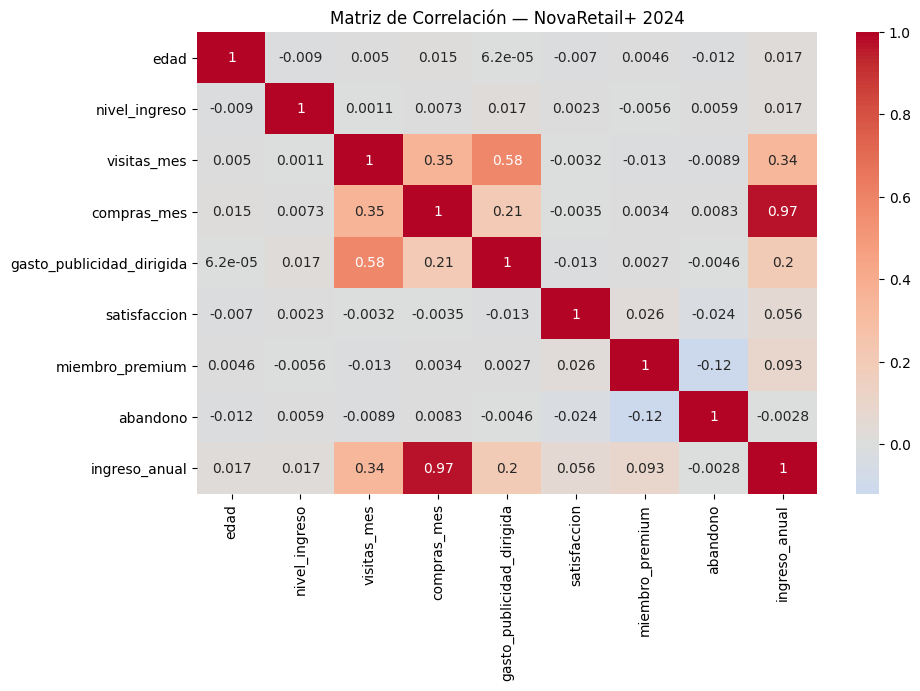

In [9]:
# Matriz de correlación visualizada como heatmap
corr_matrix = df.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title("Matriz de Correlación — NovaRetail+ 2024")
plt.show()

**Diagnóstico del Heatmap:**
- **Variables aisladas:** `edad`, `nivel_ingreso`, `satisfaccion`, `miembro_premium` y `abandono` presentan valores cercanos a cero con todas las demás — sin relación lineal con el comportamiento de compra ni el churn
- **Triada del comportamiento de compra:**
  - `visitas_mes` ↔ `compras_mes` (0.35): relación positiva moderada
  - `visitas_mes` ↔ `gasto_publicidad_dirigida` (0.58): relación positiva moderada-fuerte — la publicidad co-existe con mayor tráfico
- **Señal crítica:** `compras_mes` ↔ `ingreso_anual` muestra el bloque más oscuro del heatmap — posible colinealidad a investigar
- **Variable objetivo (`abandono`):**
    - La variable `abandono` no presenta correlaciones lineales fuertes con ninguna de las variables analizadas. La más destacable se observa con `miembro_premium`, con una correlación negativa débil de **-0.12**, sugiriendo que los clientes premium tienden ligeramente menos a abandonar el servicio.
    - ⚠ **Importante:** dado que ambas variables son binarias, esta evidencia debe considerarse únicamente exploratoria. La asociación se validará posteriormente mediante el **coeficiente de correlación Punto-Biserial**, más apropiado para este tipo de variables.

**Análisis de `ingreso_anual`:**
- **Correlación extremadamente alta con `compras_mes` (0.97):** ambas variables presentan una relación casi perfecta, indicando que aumentan de forma prácticamente proporcional. Esto sugiere que `compras_mes` podría estar capturando gran parte de la información contenida en `ingreso_anual`, ya que un mayor volumen de compras se traduce directamente en mayores ingresos para la empresa.
    - Desde una perspectiva analítica, esta relación puede resultar redundante y constituye una posible fuente de **colinealidad**, por lo que debe evaluarse cuidadosamente antes de incluir ambas variables en modelos predictivos.
- **Relación moderada con `visitas_mes` (0.34):** los usuarios con mayor actividad tienden a generar mayores ingresos, aunque la asociación es considerablemente menor que la observada con las compras.
- **Relación débil con `gasto_publicidad_dirigida` (0.20):** existe una asociación positiva, pero de baja magnitud, entre la inversión publicitaria y los ingresos generados.
- **Práctica independencia respecto a otras variables:** `ingreso_anual` muestra correlaciones prácticamente nulas con `nivel_ingreso` (0.017), `edad` (0.017), `abandono` (-0.003) y `satisfaccion` (0.056), lo que indica ausencia de relaciones lineales relevantes con estos factores.

### Análisis Bivariado — Scatterplots de Relaciones Clave

Se seleccionaron las 3 variables con mayor correlación visual con `ingreso_anual` para análisis detallado.

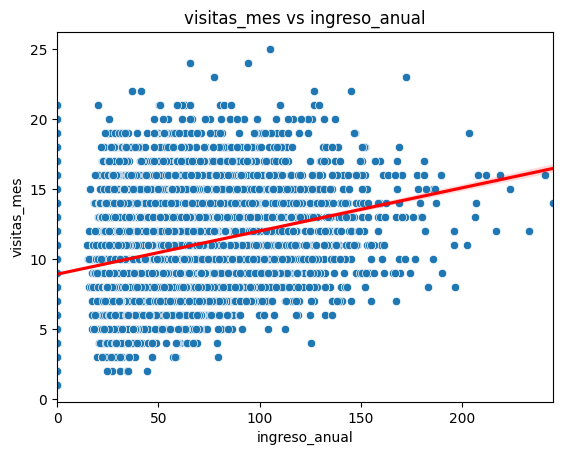

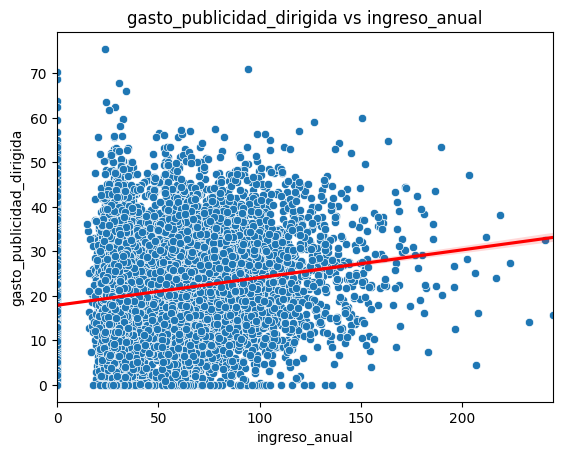

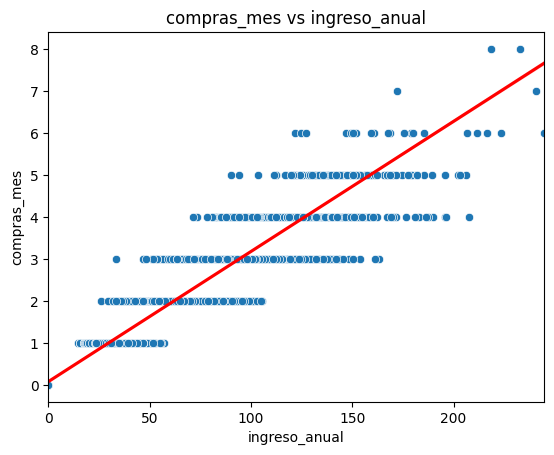

In [10]:
# Scatterplots de variables con relaciones moderadas o fuertes
par_variables_fuertes = ['visitas_mes', 'gasto_publicidad_dirigida', 'compras_mes']
for col in par_variables_fuertes:
    sns.scatterplot(data=df, x="ingreso_anual", y=col)
    sns.regplot(data=df, x="ingreso_anual", y=col, 
                scatter=False, color="red")
    plt.title(f'{col} vs ingreso_anual')
    plt.show()

**Diagnóstico de Scatterplots:**

**`visitas_mes` vs `ingreso_anual`:**
- Dirección positiva con dispersión media-alta
- Outliers bajos/moderados en usuarios con más de 20-25 visitas
- Sin riesgo de colinealidad (correlación 0.34, nube amplia)

**`gasto_publicidad_dirigida` vs `ingreso_anual`:**
- Dirección positiva muy leve con dispersión alta
- Grupo denso acumulado en $0 de ingreso_anual (usuarios inactivos)
- Sin riesgo de colinealidad (correlación débil 0.20)

**`compras_mes` vs `ingreso_anual`:**
- Dirección positiva casi perfecta con dispersión muy baja
- Estructura escalonada por valores enteros de `compras_mes`
- **Riesgo crítico de multicolinealidad confirmado** (correlación 0.97)

## Evidencia Numérica — Coeficientes de Correlación

### Pearson y Spearman (Variables Numéricas)

In [11]:
# Función de correlación numérica con ambos métodos
def corr_numerica(df, columnas, metodo='pearson'):
    matriz = columnas.corr(method=metodo)
    return matriz

In [12]:
# Correlación Pearson
col_analisis = ['visitas_mes', 'compras_mes', 'gasto_publicidad_dirigida', 'ingreso_anual']
print("--- Pearson ---")
corr_numerica(df, df[col_analisis], 'pearson').round(4)

--- Pearson ---


,visitas_mes,compras_mes,gasto_publicidad_dirigida,ingreso_anual
visitas_mes,1.0000,0.3538,0.5789,0.3371
compras_mes,0.3538,1.0000,0.2075,0.9671
gasto_publicidad_dirigida,0.5789,0.2075,1.0000,0.1975
ingreso_anual,0.3371,0.9671,0.1975,1.0000


In [13]:
print("--- Spearman ---")
corr_numerica(df, df[col_analisis], 'spearman').round(4)

--- Spearman ---


,visitas_mes,compras_mes,gasto_publicidad_dirigida,ingreso_anual
visitas_mes,1.0000,0.3329,0.5593,0.3210
compras_mes,0.3329,1.0000,0.1925,0.9675
gasto_publicidad_dirigida,0.5593,0.1925,1.0000,0.1850
ingreso_anual,0.3210,0.9675,0.1850,1.0000


**Diagnóstico Pearson / Spearman:**

- Ambos coeficientes muestran resultados muy similares — las relaciones son predominantemente lineales además de monótonas

**`compras_mes` vs `ingreso_anual`:**
- Pearson: **0.967** · Spearman: **0.967**
- Asociación directa casi perfecta — colinealidad confirmada

**`visitas_mes` vs `gasto_publicidad_dirigida`:**
- Pearson: **0.579** · Spearman: **0.559**
- Segunda relación más fuerte del dataset — moderada-fuerte

**`gasto_publicidad_dirigida` vs `ingreso_anual`:**
- Pearson: **~0.20** · Spearman: **~0.19**
- Relación débil — desconexión entre atracción publicitaria y conversión en ingresos

### Correlación Punto Biserial (Variables Binarias)

In [14]:
# Correlación Punto Biserial — variables binarias vs ingreso_anual
col_binarias = ['miembro_premium', 'abandono']

def corr_biserial(df, ingreso_anual, col_binarias):
    for col in col_binarias:
        resultado = pointbiserialr(df['ingreso_anual'], df[col])
        print(f"Punto-Biserial {col}: {resultado.statistic:.3f}")

corr_biserial(df, df['ingreso_anual'], col_binarias)

Punto-Biserial miembro_premium: 0.093
Punto-Biserial abandono: -0.003


**Diagnóstico Punto Biserial:**

**`miembro_premium` vs `ingreso_anual` (0.093):**
- Relación directa muy leve — a mayor ingreso, levemente más probable ser Premium, pero no es un factor determinante

**`abandono` vs `ingreso_anual` (-0.003):**
- Relación prácticamente inexistente — el ingreso anual no influye en absoluto en la probabilidad de churn

### V de Cramér (Variables Categóricas)

In [15]:
# Función para calcular V de Cramér
def cramer_v(df, col1, col2):
    tabla = pd.crosstab(df[col1], df[col2])
    chi2, _, _, _ = chi2_contingency(tabla)
    n = tabla.sum().sum()
    v_cramer = np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))
    return v_cramer

In [16]:
# Asociación entre tipo de dispositivo y región geográfica
v_cramer_resultado = cramer_v(df, 'tipo_dispositivo', 'region')
print(f"Asociación Dispositivo vs Región: {v_cramer_resultado:.3f}")

Asociación Dispositivo vs Región: 0.012


**Diagnóstico V de Cramér (0.012):**

Asociación prácticamente inexistente entre `tipo_dispositivo` y `region`. La distribución de dispositivos es homogénea en todas las regiones geográficas — el canal de acceso no depende de la ubicación del cliente.

## 5. Hallazgos Principales

### Hallazgo 1 — Redundancia del Volumen de Transacciones
*(compras_mes vs ingreso_anual)*

**Evidencia visual:** Scatterplot diagonal compacto y escalonado 
por valores enteros de `compras_mes`.

**Evidencia numérica:** Pearson = Spearman = **0.967**

**Interpretación:** Co-movimiento directo y simétrico casi perfecto entre transacciones mensuales e ingreso generado. Ambas variables 
capturan la misma información financiera — colinealidad confirmada.

**No podemos afirmar:** Que fragmentar pedidos en más compras mensuales elevará el gasto total anual del usuario.

**Implicación de negocio:** Para cualquier modelo predictivo de LTV, incluir ambas variables generará multicolinealidad — conservar solo 
`compras_mes`. Las estrategias deben enfocarse en incrementar la frecuencia de conversión real, no la navegación pasiva.

---

### Hallazgo 2 — El Motor Publicitario y la Brecha de Conversión
*(gasto_publicidad_dirigida vs visitas_mes)*

**Evidencia visual:** Bloque de color intermedio marcado en el heatmap.

**Evidencia numérica:** Pearson = **0.579** · Spearman = **0.559**

**Interpretación:** La inversión publicitaria co-existe con mayor tráfico a la plataforma — segunda relación más fuerte del dataset.

**No podemos afirmar:** Que duplicar el presupuesto publicitario disparará proporcionalmente las visitas; factores externos como 
lealtad de marca podrían estar influyendo.

**Implicación de negocio:** La publicidad está funcionando en atracción (tráfico), pero la correlación publicidad-ingreso_anual 
es baja (0.20) — existe una desconexión crítica en conversión. 
Se recomienda auditar la experiencia post-clic.

---

### Hallazgo 3 — La Paradoja del Churn Ciego al Valor
*(abandono vs ingreso_anual)*

**Evidencia visual:** Cruce neutro/grisáceo en el heatmap.

**Evidencia numérica:** Punto Biserial = **-0.003**

**Interpretación:** No existe ninguna asociación entre el valor económico del cliente y su probabilidad de abandono.

**No podemos afirmar:** Que incentivar mayor gasto protegerá al cliente del churn, ni que solo los usuarios de $0 abandonan.

**Implicación de negocio:** Los heavy users abandonan al mismo ritmo que los esporádicos — el churn es ciego al valor económico. 
La retención no se resolverá con descuentos; el equipo debe investigar disparadores cualitativos: satisfacción, logística, 
fricción en pagos.

## Limitaciones y Próximos Pasos

### Limitaciones
- **Correlación ≠ causalidad:** Todos los coeficientes reflejan co-movimiento, no relaciones causales. Factores externos no medidos (temporada, lealtad de marca) pueden influir simultáneamente
- **Multicolinealidad:** Correlación 0.97 entre `compras_mes` e `ingreso_anual` limita la utilidad de modelarlas juntas
- **Sesgo por inactividad:** ~25% de usuarios con ingreso_anual = 0 USD diluye la fuerza correlacional del segmento activo

### Próximos Pasos

**Fase 1 — Segmentación adicional:**
- Aislar usuarios activos (ingreso > 0) y repetir el análisis para obtener señales más limpias sin ruido del segmento inactivo
- Estratificar por `tipo_dispositivo` dado que +65% del tráfico proviene de móvil — los drivers de compra pueden diferir por plataforma

**Fase 2 — Experimentos controlados (A/B Testing):**
- Diseñar experimento para validar causalidad de publicidad: grupo control sin anuncios vs grupo tratamiento con anuncios, 
  midiendo impacto neto en `visitas_mes` e `ingreso_anual`

**Fase 3 — Enriquecimiento de datos:**
- Incorporar variables cualitativas para explicar el churn: tiempo de carga, fricción en pasarela de pagos, categorías 
  visitadas, historial de soporte técnico
- Habilitar modelos de regresión logística para predecir abandono de usuarios de alto valor económico

## Análisis Extendido — Iniciativa Propia

Los hallazgos del análisis correlacional principal abrieron preguntas de segmentación no exploradas. Se plantean 4 preguntas adicionales para profundizar en los patrones detectados:

1. ¿El co-movimiento entre `gasto_publicidad_dirigida` y `visitas_mes` varía entre tipos de dispositivo?
2. ¿Y entre regiones geográficas?
3. ¿La tasa de abandono es homogénea entre regiones?
4. ¿Y entre tipos de dispositivo?

> Si el churn es ciego al valor económico (Hallazgo 3), 
> ¿será también ciego a la geografía y al canal de acceso?

---

### Publicidad vs Visitas — Segmentado por Dispositivo

Correlación gasto_publicidad_dirigida vs visitas_mes por dispositivo:
------------------------------------------------------------
móvil          : Pearson = 0.5779 (n=9,818)
tablet         : Pearson = 0.5468 (n=1,462)
escritorio     : Pearson = 0.5940 (n=3,720)


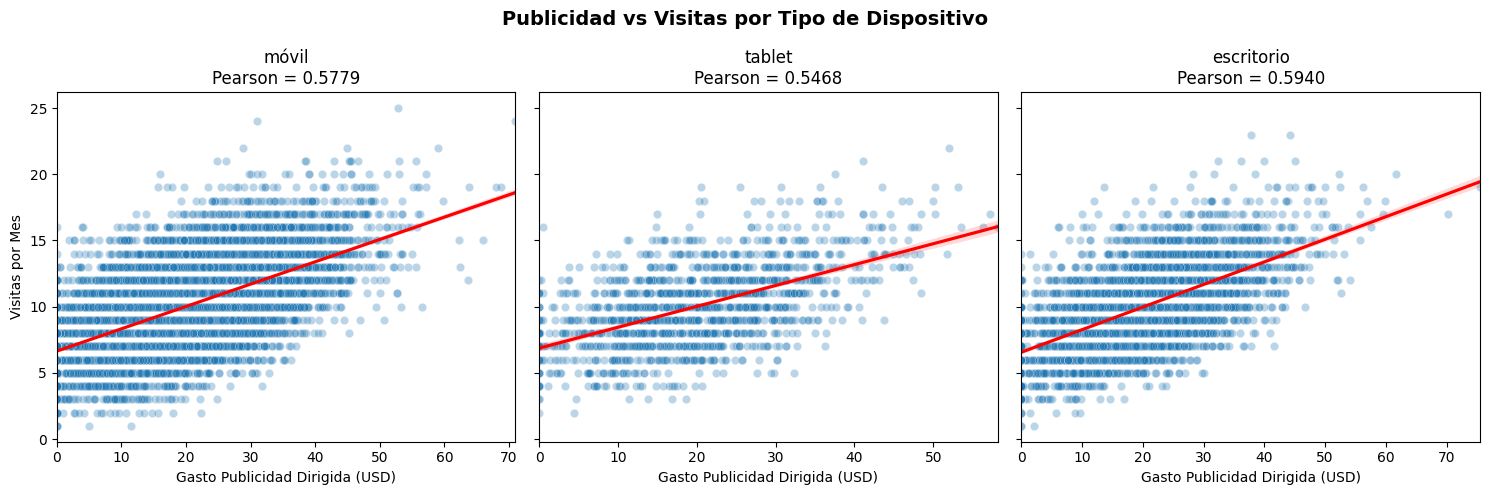

In [25]:
# Correlación gasto_publicidad_dirigida vs visitas_mes por dispositivo
dispositivos = df['tipo_dispositivo'].unique()

print("Correlación gasto_publicidad_dirigida vs visitas_mes por dispositivo:")
print("-" * 60)
for dispositivo in dispositivos:
    subset = df[df['tipo_dispositivo'] == dispositivo]
    corr = subset['gasto_publicidad_dirigida'].corr(subset['visitas_mes'])
    print(f"{dispositivo:15}: Pearson = {corr:.4f} (n={len(subset):,})")

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, dispositivo in zip(axes, dispositivos):
    subset = df[df['tipo_dispositivo'] == dispositivo]
    sns.scatterplot(data=subset, x='gasto_publicidad_dirigida',
                   y='visitas_mes', alpha=0.3, ax=ax)
    sns.regplot(data=subset, x='gasto_publicidad_dirigida',
               y='visitas_mes', scatter=False, color='red', ax=ax)
    corr = subset['gasto_publicidad_dirigida'].corr(subset['visitas_mes'])
    ax.set_title(f'{dispositivo}\nPearson = {corr:.4f}')
    ax.set_xlabel('Gasto Publicidad Dirigida (USD)')
    ax.set_ylabel('Visitas por Mes')
plt.suptitle('Publicidad vs Visitas por Tipo de Dispositivo', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Insights 7.1 — Publicidad vs Visitas por Dispositivo:**

Los tres canales mantienen una correlación positiva moderada consistente (~0.55-0.59), lo que indica que el co-movimiento entre publicidad y visitas es un patrón **robusto e independiente del dispositivo** utilizado:

| Dispositivo | Pearson | Usuarios |
|---|---|---|
| Escritorio | **0.594** | 3,720 |
| Móvil | 0.578 | 9,818 |
| Tablet | 0.547 | 1,462 |

- **Escritorio** presenta la correlación más alta (0.594), sugiriendo que en este canal la publicidad tiene el mayor co-movimiento con las visitas
- **Tablet** registra la correlación más baja (0.547), aunque la diferencia entre los tres dispositivos es marginal (~0.05), lo que descarta una segmentación radical por canal
- **Recomendación:** Dado que **móvil concentra el 65%+ de los usuarios** (9,818) y mantiene una correlación moderada-alta (0.578), representa el mayor retorno absoluto de inversión publicitaria. Priorizar el presupuesto en móvil maximiza el alcance sin sacrificar efectividad.

### Publicidad vs Visitas — Segmentado por Región

Correlación gasto_publicidad_dirigida vs visitas_mes por región:
------------------------------------------------------------
norte     : Pearson = 0.5968 (n=4,395)
sur       : Pearson = 0.5652 (n=3,726)
este      : Pearson = 0.5722 (n=3,069)
oeste     : Pearson = 0.5771 (n=3,810)


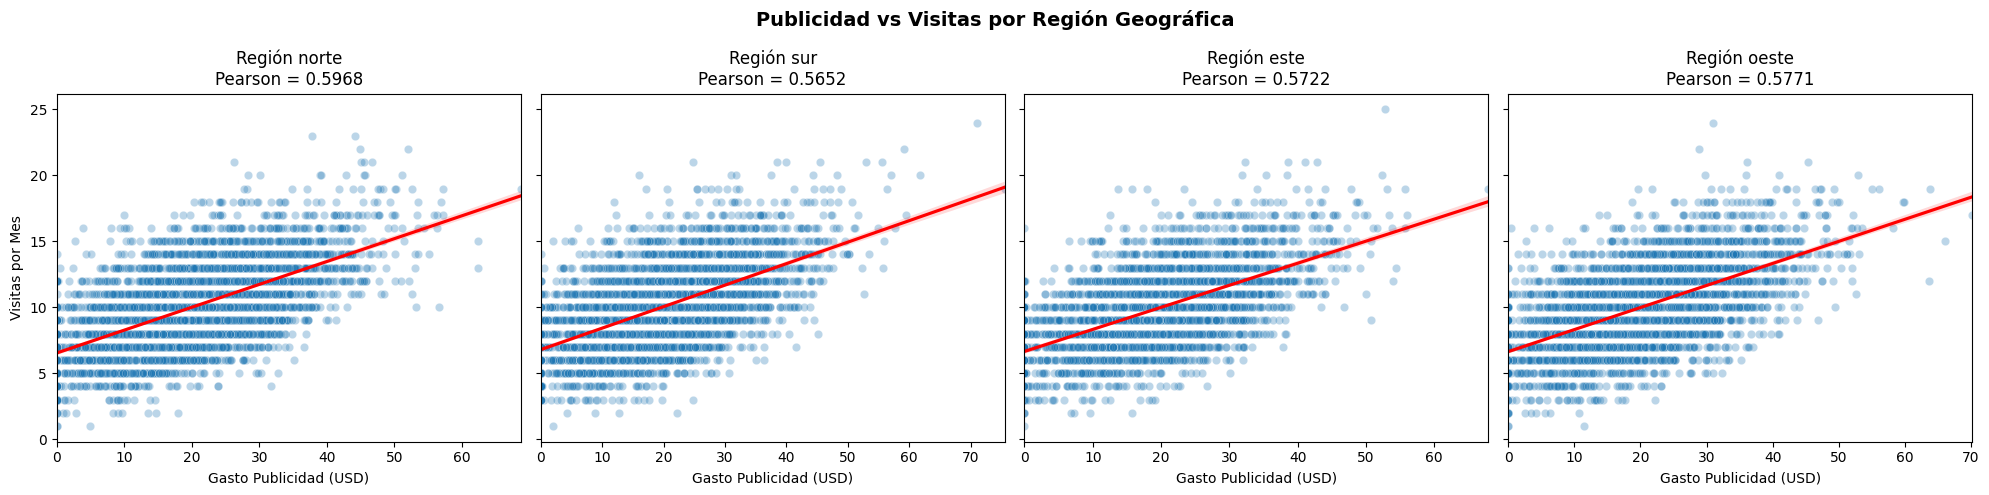

In [26]:
# Correlación gasto_publicidad_dirigida vs visitas_mes por región
regiones = df['region'].unique()

print("Correlación gasto_publicidad_dirigida vs visitas_mes por región:")
print("-" * 60)
for region in regiones:
    subset = df[df['region'] == region]
    corr = subset['gasto_publicidad_dirigida'].corr(subset['visitas_mes'])
    print(f"{region:10}: Pearson = {corr:.4f} (n={len(subset):,})")

# Visualización
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
for ax, region in zip(axes, regiones):
    subset = df[df['region'] == region]
    sns.scatterplot(data=subset, x='gasto_publicidad_dirigida',
                   y='visitas_mes', alpha=0.3, ax=ax)
    sns.regplot(data=subset, x='gasto_publicidad_dirigida',
               y='visitas_mes', scatter=False, color='red', ax=ax)
    corr = subset['gasto_publicidad_dirigida'].corr(subset['visitas_mes'])
    ax.set_title(f'Región {region}\nPearson = {corr:.4f}')
    ax.set_xlabel('Gasto Publicidad (USD)')
    ax.set_ylabel('Visitas por Mes')
plt.suptitle('Publicidad vs Visitas por Región Geográfica',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Insights 7.2 — Publicidad vs Visitas por Región:**

Al igual que con los dispositivos, la correlación entre publicidad y visitas es **consistente y robusta en todas las regiones**, descartando una segmentación geográfica radical:

| Región | Pearson | Usuarios |
|---|---|---|
| Norte | **0.597** | 4,395 |
| Oeste | 0.577 | 3,810 |
| Este | 0.572 | 3,069 |
| Sur | **0.565** | 3,726 |

- La diferencia máxima entre regiones es de apenas **~0.03 puntos**, lo que confirma que el co-movimiento publicidad-visitas es un patrón **estructural del negocio**, no un fenómeno geográfico
- **Norte** lidera en correlación (0.597) y en volumen de usuarios (4,395) — doble ventaja para priorización presupuestal
- **Sur y Este** presentan la correlación más baja y menor base de usuarios simultáneamente

- **Recomendación:** Distribución presupuestal casi igualitaria entre las 4 regiones con una asignación marginalmente mayor al **Norte** por su doble ventaja (mayor correlación + mayor volumen), y ligeramente menor en **Sur y Este** por su menor base de usuarios y efectividad relativa más baja.

> **Hallazgo transversal 7.1-7.2:** La relación publicidad-visitas es **invariante al canal y a la geografía** — su fuerza moderada (~0.58) se mantiene constante independientemente del segmento analizado, sugiriendo que el driver real de visitas es el presupuesto publicitario en sí mismo, no el medio ni la región.

### Tasa de Abandono — Segmentado por Región

  region  usuarios_churn  total_usuarios  tasa_churn  tasa_churn_pct
2  oeste             600            3810    0.157480           15.75
3    sur             576            3726    0.154589           15.46
0   este             451            3069    0.146953           14.70
1  norte             634            4395    0.144255           14.43


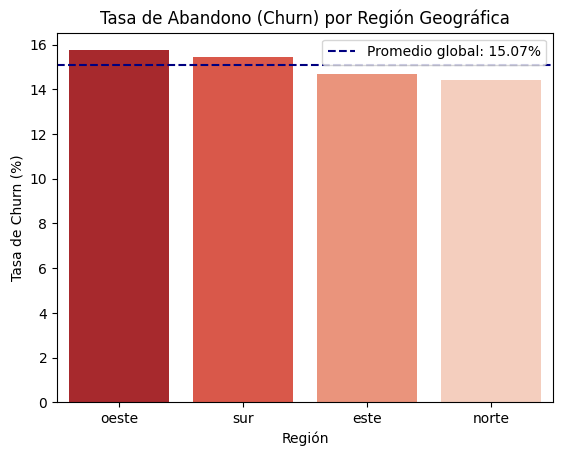

In [29]:
# Tasa de abandono por región
churn_region = df.groupby('region')['abandono'].agg(['sum', 'count', 'mean'])\
    .rename(columns={'sum': 'usuarios_churn','count': 'total_usuarios','mean': 'tasa_churn'})\
    .reset_index()
churn_region['tasa_churn_pct'] = (churn_region['tasa_churn'] * 100).round(2)
churn_region = churn_region.sort_values('tasa_churn_pct', ascending=False)
print(churn_region)

# Visualización
sns.barplot(data=churn_region, x='region', y='tasa_churn_pct',
            palette='Reds_r')
plt.title('Tasa de Abandono (Churn) por Región Geográfica')
plt.xlabel('Región')
plt.ylabel('Tasa de Churn (%)')
plt.axhline(y=df['abandono'].mean()*100, color='navy', 
            linestyle='--', label=f'Promedio global: {df["abandono"].mean()*100:.2f}%')
plt.legend()
plt.show()

**Insights 7.3 — Churn por Región:**

| Región | Usuarios Churn | Total | Tasa Churn |
|---|---|---|---|
| Oeste | 600 | 3,810 | **15.75%** |
| Sur | 576 | 3,726 | 15.46% |
| Este | 451 | 3,069 | 14.70% |
| Norte | 634 | 4,395 | **14.43%** |
| **Promedio global** | | | **15.07%** |

- La diferencia máxima entre regiones es de apenas **~1.3 puntos porcentuales** (oeste 15.75% vs norte 14.43%), una variación estadísticamente insignificante
- **El churn es geográficamente homogéneo** — ninguna región supera el promedio global de forma significativa
- Oeste y Sur superan marginalmente el promedio (+0.68% y +0.39% respectivamente), pero no justifican campañas de retención geográficamente diferenciadas

> **Confirmación del Hallazgo 3:** El churn no solo es ciego al valor económico del cliente — también es **ciego a la geografía**. El abandono es un fenómeno estructural de la plataforma, no regional.

**Recomendación:** Descartar segmentación geográfica para campañas de retención. Investigar disparadores cualitativos transversales: experiencia de usuario, usabilidad de la plataforma, fricción en pagos y tiempos de respuesta de soporte técnico.

### Tasa de Abandono — Segmentado por Dispositivo

  tipo_dispositivo  usuarios_churn  total_usuarios  tasa_churn  tasa_churn_pct
2           tablet             228            1462    0.155951           15.60
0       escritorio             571            3720    0.153495           15.35
1            móvil            1462            9818    0.148910           14.89


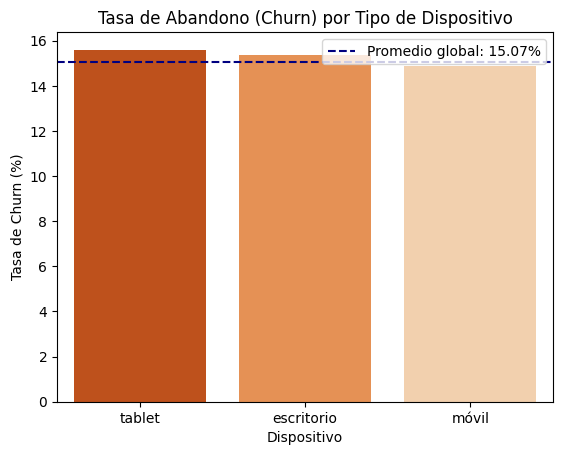

In [30]:
# Tasa de abandono por tipo de dispositivo
churn_dispositivo = df.groupby('tipo_dispositivo')['abandono'].agg(['sum', 'count', 'mean'])\
    .rename(columns={'sum': 'usuarios_churn','count': 'total_usuarios', 'mean': 'tasa_churn'})\
    .reset_index()
churn_dispositivo['tasa_churn_pct'] = (churn_dispositivo['tasa_churn'] * 100).round(2)
churn_dispositivo = churn_dispositivo.sort_values('tasa_churn_pct', ascending=False)
print(churn_dispositivo)

# Visualización
sns.barplot(data=churn_dispositivo, x='tipo_dispositivo', 
            y='tasa_churn_pct', palette='Oranges_r')
plt.title('Tasa de Abandono (Churn) por Tipo de Dispositivo')
plt.xlabel('Dispositivo')
plt.ylabel('Tasa de Churn (%)')
plt.axhline(y=df['abandono'].mean()*100, color='navy',
            linestyle='--', label=f'Promedio global: {df["abandono"].mean()*100:.2f}%')
plt.legend()
plt.show()

**Insights 7.4 — Churn por Dispositivo:**

| Dispositivo | Usuarios Churn | Total | Tasa Churn |
|---|---|---|---|
| Tablet | 228 | 1,462 | **15.60%** |
| Escritorio | 571 | 3,720 | 15.35% |
| Móvil | 1,462 | 9,818 | **14.89%** |
| **Promedio global** | | | **15.07%** |

- La diferencia máxima entre dispositivos es de apenas **~0.71 puntos porcentuales** (tablet 15.60% vs móvil 14.89%)
- **El churn es homogéneo entre dispositivos** — ningún canal presenta una tasa de abandono significativamente diferente al promedio global
- **Móvil** registra la tasa más baja (14.89%) a pesar de concentrar el 65%+ de los usuarios — sugiere mayor fidelización en el canal dominante
- **Tablet** supera marginalmente el promedio (+0.53%) siendo el canal con menor base de usuarios

> **Confirmación extendida del Hallazgo 3:** El churn es ciego al valor económico, a la geografía **y al canal de acceso**. 
> El abandono es un fenómeno estructural y transversal de NovaRetail+, independiente de cómo, dónde o con qué dispositivo el usuario accede a la plataforma.

**Recomendación:** Priorizar una mejora de experiencia de usuario **general** en toda la plataforma, con atención marginal a la experiencia en **tablet** por su churn ligeramente superior. 
La investigación de disparadores cualitativos debe ser multi-canal y multi-región simultáneamente, dado que el abandono no responde a ninguna segmentación detectada.

In [32]:
# Exportación del dataset con columnas limpias
df.to_csv('novaretail_analisis_correlacional_2024.csv', 
          index=False, encoding='utf-8-sig')
print("Dataset exportado exitosamente.")

Dataset exportado exitosamente.
